In [2]:
#celda 1

import pandas as pd
import matplotlib.pyplot as plt
import nltk

In [3]:
#celda 2
total_df = pd.read_csv('df_total.csv')
total_df.info()

print()
cantidad_documentos = total_df.shape[0]

print(f"El corpus tiene {cantidad_documentos} documentos.")
print("Columnas del corpus:", total_df.columns.tolist())
total_df.head()



<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     1217 non-null   str  
 1   news    1217 non-null   str  
 2   Type    1217 non-null   str  
dtypes: str(3)
memory usage: 28.7 KB

El corpus tiene 1217 documentos.
Columnas del corpus: ['url', 'news', 'Type']


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?**

El corpus tiene 1217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?**

url: enlace a la noticia original.

news: texto completo de la noticia.

Type: categoría/etiqueta asignada a la noticia.

In [4]:
#celda 3
print("Cantidad de categorías:", total_df['Type'].nunique())
print()
print("Distribución:")
print(total_df['Type'].value_counts())
print()
print("Distribución (%):")
print((total_df['Type'].value_counts(normalize=True) * 100).round(2))

Cantidad de categorías: 7

Distribución:
Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

Distribución (%):
Type
Macroeconomia     27.94
Alianzas          20.30
Innovacion        16.02
Regulaciones      11.67
Sostenibilidad    11.26
Otra              10.68
Reputacion         2.14
Name: proportion, dtype: float64


In [5]:
#celda 4
print("Filas totalmente duplicadas:", total_df.duplicated().sum())
print("News (texto) duplicado:", total_df.duplicated(subset='news').sum())
print()
print("Valores nulos por columna:")
print(total_df.isnull().sum())
print()
print("Filas con texto vacío en news:", (total_df['news'].str.strip() == '').sum())

Filas totalmente duplicadas: 75
News (texto) duplicado: 79

Valores nulos por columna:
url     0
news    0
Type    0
dtype: int64

Filas con texto vacío en news: 4


**¿Cuántas categorías hay y cómo se distribuyen?**

El corpus tiene 7 categorías: Macroeconomia, Alianzas, 
Innovación, Regulaciones, Sostenibilidad, Otra y Reputación. No están nada balanceadas, solo macroeconomía tiene 
casi 3 veces más noticias que Regulaciones o Sostenibilidad, y Reputacion es casi indiferente, ya que es bastante pequeña comparada con las demás.

**¿Hay filas vacías o duplicadas?**

Sí, hay 75 filas duplicadas y 79 noticias con el mismo texto, aunque no coincidan exactamente todas las columnas. No hay valores nulos en ninguna columna, pero sí hay 4 filas donde el texto de la noticia está vacío.

In [6]:
#celda 5
total_df = total_df.drop_duplicates(subset='news').dropna(subset=['news']).reset_index(drop=True)
print(f"limpió {total_df.shape[0]} datos")


limpió 1138 datos


In [7]:
#celda 6
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

resumen_pipeline = []

def contar_tokens_tipos(serie_de_listas):
    tokens = [t for doc in serie_de_listas for t in doc]
    tipos = set(tokens)
    return len(tokens), len(tipos)

# i. Tokenización
total_df['tok'] = total_df['news'].apply(lambda x: word_tokenize(x, language='spanish'))
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Tokenización', n_tok, n_tip))
print(f"Tokenización: {n_tok} tokens, {n_tip} tipos")

# ii. Minúsculas
total_df['tok'] = total_df['tok'].apply(lambda toks: [t.lower() for t in toks])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Minúsculas', n_tok, n_tip))
print(f"Minúsculas: {n_tok} tokens, {n_tip} tipos")

# iii. Eliminar puntuación
puntuacion = set(string.punctuation + '¿¡""''—…')
total_df['tok'] = total_df['tok'].apply(
    lambda toks: [t for t in toks if t not in puntuacion and any(c.isalnum() for c in t)]
)
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin puntuación', n_tok, n_tip))
print(f"Sin puntuación: {n_tok} tokens, {n_tip} tipos")

# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
total_df['tok'] = total_df['tok'].apply(lambda toks: [t for t in toks if t not in stop_es])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin stopwords', n_tok, n_tip))
print(f"Sin stopwords: {n_tok} tokens, {n_tip} tipos")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokenización: 631481 tokens, 39017 tipos
Minúsculas: 631481 tokens, 36178 tipos
Sin puntuación: 598368 tokens, 36142 tipos
Sin stopwords: 318949 tokens, 35931 tipos


In [8]:
#celda 7
import spacy
nlp = spacy.load('es_core_news_sm')

def lematizar_batch(lista_de_listas_tokens, batch_size=50):
    textos = [' '.join(toks) for toks in lista_de_listas_tokens]
    resultados = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        resultados.append([tok.lemma_ for tok in doc])
    return resultados

total_df['tok'] = lematizar_batch(total_df['tok'])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Lematizado', n_tok, n_tip))
print(f"Lematizado: {n_tok} tokens, {n_tip} tipos")

Lematizado: 319667 tokens, 28801 tipos


In [9]:
#celda 8
resumen_df = pd.DataFrame(resumen_pipeline, columns=['Paso', 'Tokens', 'Tipos'])
tipos_original = resumen_df.loc[0, 'Tipos']
resumen_df['% reducción tipos vs original'] = ((tipos_original - resumen_df['Tipos']) / tipos_original * 100).round(2)
resumen_df

,Paso,Tokens,Tipos,% reducción tipos vs original
0,Tokenización,631481,39017,0.00
1,Minúsculas,631481,36178,7.28
2,Sin puntuación,598368,36142,7.37
3,Sin stopwords,318949,35931,7.91
4,Lematizado,319667,28801,26.18


### ¿Qué es un EDA?

Un Análisis Exploratorio de Datos (EDA) es básicamente lo primero que uno tiene cuando están los datos antes de meterles cualquier modelo. Consiste en revisar el dataset con estadísticas descriptivas y gráficos para entender cómo está armado, cómo se distribuye la información, si hay  problemas de calidad y si hay algo raro o inesperados.

### ¿Qué busca lograr un EDA dentro de un proyecto de ciencia de datos?

Entender qué tan grande es el dataset y cómo está estructurado (por ejemplo cuántas filas, columnas, qué tipo de dato hay en cada una).


Encontrar problemas como valores nulos, filas duplicadas, outliers o cosas que no cuadran.


Detectar patrones o relaciones entre variables que después sirvan para decidir cómo modelar.


Armar hipótesis desde el principio, antes de empezar formalmente el modelado.


Decidir qué tipo de preprocesamiento hace falta (normalizar, transformar, elegir variables).


In [10]:
#celda 9
n_tokens_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tokens'].values[0]
n_tipos_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tipos'].values[0]
ttr_global = n_tipos_final / n_tokens_final
print(f"TTR global (normalizado): {ttr_global:.4f}")

def ttr_por_categoria(df, col_tokens='tok', col_cat='Type'):
    filas = []
    for cat, grupo in df.groupby(col_cat):
        tokens = [t for lista in grupo[col_tokens] for t in lista]
        tipos = set(tokens)
        ttr = len(tipos)/len(tokens) if tokens else 0
        filas.append((cat, len(tokens), len(tipos), round(ttr, 4)))
    return pd.DataFrame(filas, columns=['Categoría','Tokens','Tipos','TTR'])

ttr_cat_df = ttr_por_categoria(total_df)
ttr_cat_df

TTR global (normalizado): 0.0901


,Categoría,Tokens,Tipos,TTR
0,Alianzas,48898,9956,0.2036
1,Innovacion,50846,7068,0.1390
2,Macroeconomia,93245,11895,0.1276
3,Otra,28357,5813,0.2050
4,Regulaciones,37162,8032,0.2161
5,Reputacion,7704,2702,0.3507
6,Sostenibilidad,53455,8252,0.1544


In [11]:
#celda 10
from collections import Counter

todos_tokens = [t for lista in total_df['tok'] for t in lista]
frecuencias = Counter(todos_tokens)

freq_df = pd.DataFrame(frecuencias.most_common(20), columns=['palabra', 'frecuencia'])
freq_df

,palabra,frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


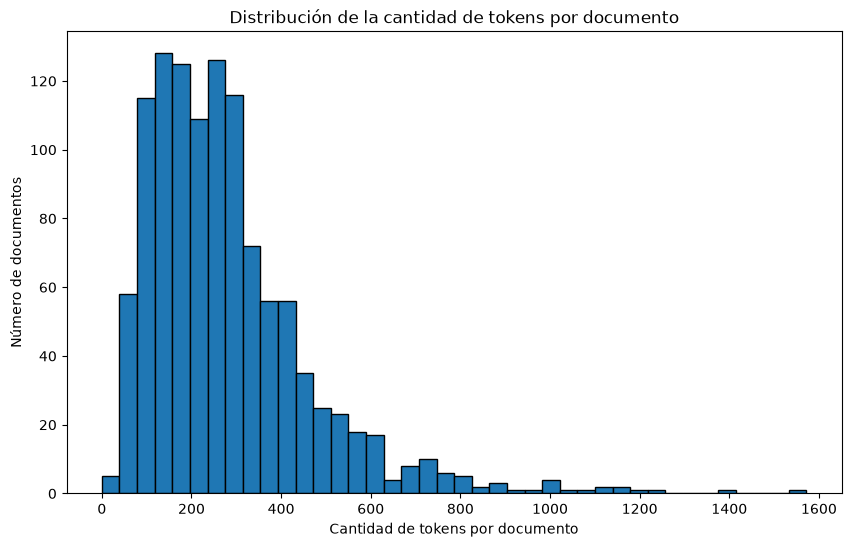

In [12]:
#celda 11
total_df['n_tokens_doc'] = total_df['tok'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(total_df['n_tokens_doc'], bins=40, edgecolor='black')
plt.xlabel('Cantidad de tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de la cantidad de tokens por documento')
plt.show()

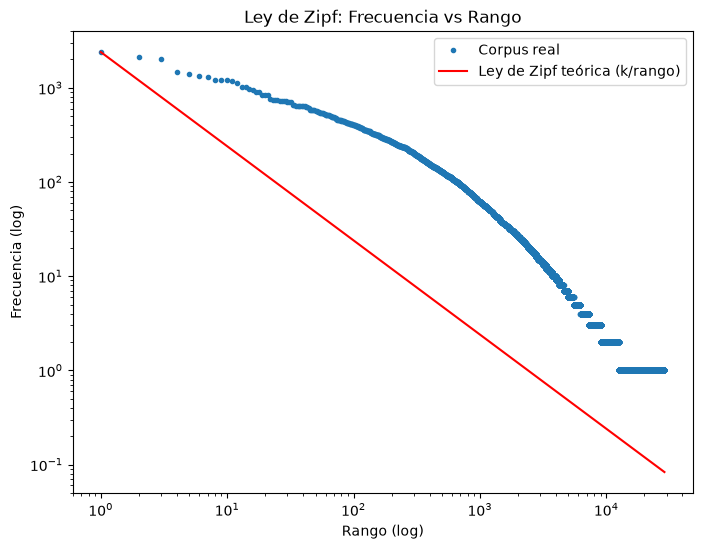

In [13]:
#celda 12
import numpy as np

frecs_ordenadas = sorted(frecuencias.values(), reverse=True)
rangos = np.arange(1, len(frecs_ordenadas) + 1)

k = frecs_ordenadas[0]
zipf_teorico = k / rangos

plt.figure(figsize=(8, 6))
plt.loglog(rangos, frecs_ordenadas, marker='.', linestyle='none', label='Corpus real')
plt.loglog(rangos, zipf_teorico, color='red', label='Ley de Zipf teórica (k/rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.title('Ley de Zipf: Frecuencia vs Rango')
plt.legend()
plt.show()

In [14]:
#celda 13
categorias_a_comparar = total_df['Type'].unique()[:2]  # cambia por las categorías que prefieras

for cat in categorias_a_comparar:
    subset = total_df[total_df['Type'] == cat]
    tokens_cat = [t for lista in subset['tok'] for t in lista]
    frec_cat = Counter(tokens_cat)
    print(f"\nTop 10 palabras — Categoría: {cat}")
    for palabra, freq in frec_cat.most_common(10):
        print(f"  {palabra}: {freq}")


Top 10 palabras — Categoría: Otra
  banco: 386
  bbva: 332
  millón: 275
  financiero: 217
  año: 206
  entidad: 195
  poder: 164
  crédito: 157
  cliente: 142
  tasa: 139

Top 10 palabras — Categoría: Regulaciones
  poder: 275
  decir: 233
  regulación: 230
  empresa: 220
  país: 214
  mercado: 185
  servicio: 173
  hacer: 171
  año: 170
  nuevo: 168


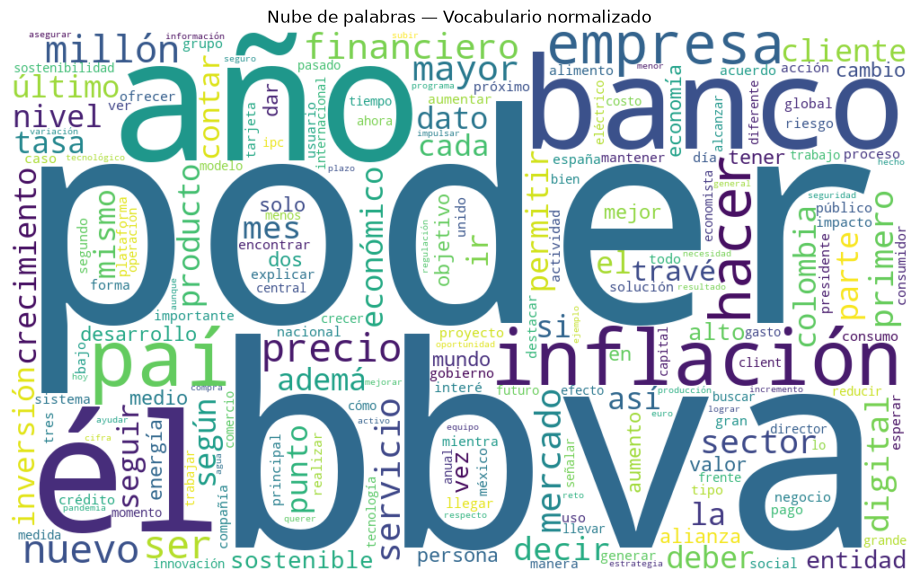

In [15]:
#celda 14
from wordcloud import WordCloud

texto_normalizado = ' '.join(todos_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_normalizado)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Vocabulario normalizado')
plt.show()

# Laboratorio 2: Representaciones de texto

In [16]:
#celda 15
total_df['texto_normalizado'] = total_df['tok'].apply(lambda toks: ' '.join(toks))
total_df['texto_normalizado'].head()

0    foro banca articulador empresarial desarrollo ...
1    regulador valor chino decir domingo buscar coo...
2    industria históricamente masculino aviación vi...
3    dato marzo ipc interanual encadenar decimoquin...
4    ayer cartagena dar inicio versión número 56 co...
Name: texto_normalizado, dtype: str

In [17]:
#celda 16
from sklearn.feature_extraction.text import CountVectorizer

vectorizador_bow = CountVectorizer()
matriz_bow = vectorizador_bow.fit_transform(total_df['texto_normalizado'])

print(f"Shape de la matriz BoW: {matriz_bow.shape}")
print(f"Número de documentos: {matriz_bow.shape[0]}")
print(f"Tamaño del vocabulario: {matriz_bow.shape[1]}")

Shape de la matriz BoW: (1138, 23409)
Número de documentos: 1138
Tamaño del vocabulario: 23409


**¿Qué se pierde y qué se gana con Bag of Words?**

Se pierde el orden de las palabras, la gramática y el contexto. Por ejemplo si hay una oracion o término y se le quita una palabra clave como un "NO", BoW no distingue negaciones ni la posición de las palabras dentro de la oración. 

Lo que se gana es que se vuelve más eficiente ya que es rápido de calcular, fácil de entender, y es util para tareas como clasificación de texto, porque muchas veces con solo saber qué palabras aparecen sin importar el orden y con eso ya alcanza para distinguir de qué tema habla un documento.

In [18]:
#celda 17
total_celdas = matriz_bow.shape[0] * matriz_bow.shape[1]
celdas_no_cero = matriz_bow.nnz 
sparsity = (1 - celdas_no_cero / total_celdas) * 100

print(f"Total de celdas: {total_celdas}")
print(f"Celdas distintas de cero: {celdas_no_cero}")
print(f"Dispersión (sparsity): {sparsity:.2f}%")

Total de celdas: 26639442
Celdas distintas de cero: 221591
Dispersión (sparsity): 99.17%


Vocabulario de 100 palabras: 68.96% de dispersión
Vocabulario de 500 palabras: 83.46% de dispersión
Vocabulario de 1000 palabras: 88.78% de dispersión
Vocabulario de 5000 palabras: 96.64% de dispersión


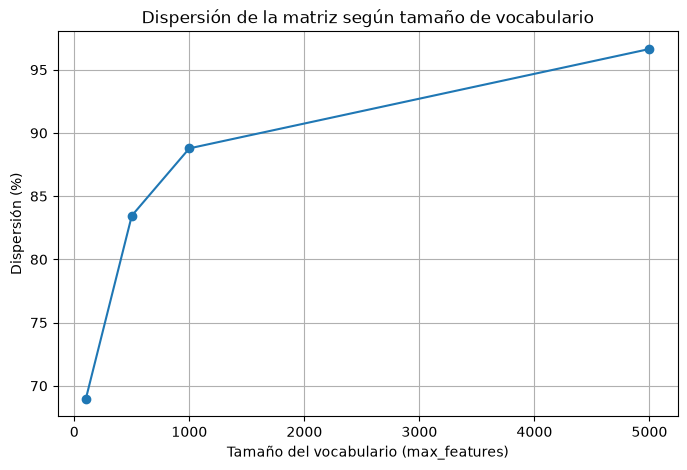

In [19]:
#celda 18
tamaños_vocabulario = [100, 500, 1000, 5000]
dispersiones = []

for tamaño in tamaños_vocabulario:
    vectorizador_prueba = CountVectorizer(max_features=tamaño)
    matriz_prueba = vectorizador_prueba.fit_transform(total_df['texto_normalizado'])
    total = matriz_prueba.shape[0] * matriz_prueba.shape[1]
    no_cero = matriz_prueba.nnz
    disp = (1 - no_cero / total) * 100
    dispersiones.append(disp)
    print(f"Vocabulario de {tamaño} palabras: {disp:.2f}% de dispersión")

plt.figure(figsize=(8, 5))
plt.plot(tamaños_vocabulario, dispersiones, marker='o')
plt.xlabel('Tamaño del vocabulario (max_features)')
plt.ylabel('Dispersión (%)')
plt.title('Dispersión de la matriz según tamaño de vocabulario')
plt.grid(True)
plt.show()

**¿por qué crece la dispersión al aumentar el vocabulario? ¿Qué
implicaciones tiene esto en el costo de almacenamiento y de cómputo?** 


Porque cada documento sigue teniendo mas o menos la misma cantidad de palabras, pero el espacio de columnas disponibles si crece. Entonces si un documento usa 150 palabras distintas y el vocabulario total es de 500, ese documento llena mucho mas el espacio de las columnas. Esto tiene implicaciones directas en almacenamiento, ya que guardar todos esos ceros de forma literal desperdicia un montón la memoria, y hacer cálculos  sobre una matriz gigante es mas exigente para la computadora.


**¿Qué es una matriz dispersa (sparse matrix)?**

Es una estructura de datos especial que, en lugar de guardar todos los números de la matriz (incluyendo los millones de ceros), solo guarda las posiciones y valores de las celdas que NO son cero. 

In [20]:
#celda 19
vectorizador_unigramas = CountVectorizer(ngram_range=(1, 1))
matriz_unigramas = vectorizador_unigramas.fit_transform(total_df['texto_normalizado'])

vectorizador_bigramas = CountVectorizer(ngram_range=(2, 2))
matriz_bigramas = vectorizador_bigramas.fit_transform(total_df['texto_normalizado'])

print(f"Vocabulario con unigramas: {matriz_unigramas.shape[1]} términos")
print(f"Vocabulario con bigramas: {matriz_bigramas.shape[1]} términos")

Vocabulario con unigramas: 23409 términos
Vocabulario con bigramas: 227577 términos


In [21]:
#celda 20
frecuencia_total_bigramas = matriz_bigramas.sum(axis=0)
vocabulario_bigramas = vectorizador_bigramas.get_feature_names_out()

lista_frecuencias_bigramas = [(vocabulario_bigramas[i], frecuencia_total_bigramas[0, i]) for i in range(len(vocabulario_bigramas))]
bigramas_ordenados = sorted(lista_frecuencias_bigramas, key=lambda x: x[1], reverse=True)

top_bigramas = pd.DataFrame(bigramas_ordenados[:15], columns=['bigrama', 'frecuencia'])
top_bigramas

,bigrama,frecuencia
0,banco central,219
1,poder ser,201
2,bbva research,200
3,tasa interés,189
4,cada vez,184
5,entidad financiero,160
6,cambio climático,157
7,punto básico,139
8,año pasado,136
9,bbva méxico,134


**¿Los bigramas aportan información que los unigramas no capturan?**

Sí, varios de los bigramas son términos que si separamos las palabras y las leemos así individualmente, el término deja de tener sentido. Por ejemplo, banco central, tasa interés, cambio climático y entre otros, son términos económicos que si los separás en dos palabras sueltas se pierde esa unidad de significado.

**Ventajas y costo de los bigramas/trigramas frente a unigramas:**

Una ventaja puede ser que dan un poco de contexto y orden local, entonces permite distinguir frases con significado propio que como palabras sueltas no significa lo mismo. 
Por otro lado, una desventaja es que el vocabulario es demasiado grande, es decir, pasamos de 23,409 a 227,577 términos. Esto también significa que la matriz de bigramas va a ser miuchisimo más dispersa que la de unigramas.

In [22]:
#celda 21
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer()
matriz_tfidf = vectorizador_tfidf.fit_transform(total_df['texto_normalizado'])
vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()

print(f"Shape de la matriz TF-IDF: {matriz_tfidf.shape}")

Shape de la matriz TF-IDF: (1138, 23409)


In [23]:
#celda 22
import numpy as np

categorias_unicas = total_df['Type'].unique()[:3]
indices_ejemplo = [total_df[total_df['Type'] == cat].index[0] for cat in categorias_unicas]

for idx in indices_ejemplo:
    categoria = total_df.loc[idx, 'Type']
    vector_tfidf_doc = matriz_tfidf[idx].toarray().flatten()
    indices_top_palabras = vector_tfidf_doc.argsort()[::-1][:10]
    
    print(f"\nDocumento índice {idx} — Categoría: {categoria}")
    for i in indices_top_palabras:
        if vector_tfidf_doc[i] > 0:
            print(f"  {vocabulario_tfidf[i]}: {vector_tfidf_doc[i]:.4f}")


Documento índice 0 — Categoría: Otra
  negocio: 0.2972
  garcía: 0.2377
  sostenibilidad: 0.2019
  físico: 0.1837
  sostenible: 0.1829
  prioridad: 0.1718
  imaginamos: 0.1696
  compitar: 0.1536
  articulador: 0.1536
  acá: 0.1442

Documento índice 1 — Categoría: Regulaciones
  chino: 0.5700
  cotizar: 0.2364
  extranjero: 0.2334
  sec: 0.2218
  csrc: 0.1739
  denegar: 0.1739
  empresa: 0.1562
  regulador: 0.1465
  estadounidense: 0.1290
  decir: 0.1188

Documento índice 2 — Categoría: Alianzas
  viva: 0.3193
  aerolínea: 0.2467
  aerobus: 0.1968
  us50: 0.1782
  aviación: 0.1632
  low: 0.1488
  cost: 0.1428
  avión: 0.1379
  pasajero: 0.1365
  vivo: 0.1338


In [24]:
#celda 23
for idx in indices_ejemplo:
    categoria = total_df.loc[idx, 'Type']
    tokens_doc = total_df.loc[idx, 'tok']
    conteo_doc = Counter(tokens_doc)
    print(f"\nDocumento índice {idx} — Categoría: {categoria} (top 10 por conteo simple)")
    for palabra, freq in conteo_doc.most_common(10):
        print(f"  {palabra}: {freq}")


Documento índice 0 — Categoría: Otra (top 10 por conteo simple)
  negocio: 5
  sostenible: 3
  sostenibilidad: 3
  desarrollo: 2
  garcía: 2
  importante: 2
  poder: 2
  mayor: 2
  tener: 2
  reto: 2

Documento índice 1 — Categoría: Regulaciones (top 10 por conteo simple)
  chino: 12
  empresa: 7
  decir: 5
  valor: 4
  deber: 4
  cotizar: 4
  regulador: 3
  estadounidense: 3
  extranjero: 3
  dicho: 3

Documento índice 2 — Categoría: Alianzas (top 10 por conteo simple)
  año: 4
  trabajar: 3
  bajo: 3
  aerolínea: 3
  modelo: 3
  industria: 2
  aviación: 2
  vivo: 2
  avión: 2
  llegar: 2


**¿Qué valor tienen las palabras top de TF-IDF y qué refleja su puntaje?**

Son las que mejor distinguen a cada documento del resto del corpus. Por ejemplo, en el documento de categoría Alianzas, el top de TF-IDF trae viva, aerobus, us50, low, cost. Lo cual son términos específicos de esa noticia en específico. Eso refleja que el puntaje de TF-IDF no solo mide qué tanto se repite una palabra en el documento, sino qué tan específica es esa palabra comparada con el resto del corpus.

**¿Coinciden las palabras de TF-IDF con las de conteo simple? ¿Por qué?**

Solo algunas coinciden, ya que en el documento de Otra, por conteo simple aparecen poder, importante, mayor, tener, que son mas comunes...
y estas se repiten en casi todo el corpus, pero en TF-IDF esas palabras ni siquiera entran al top 10, porque al ser tan comunes en todo el corpus su IDF está bastante bajo.

**¿Por qué TF-IDF penaliza palabras comunes y favorece palabras raras pero repetidas?**

Porque el objetivo de TF-IDF es medir qué tan única es una palabra para un documento. Entonces si una palabra aparece en casi todos los documentos del corpus, no sirve para diferenciar un documento de otro, entonces el IDF le baja el puntaje aunque el TF sea alto.

In [25]:
#celda 24
from sklearn.metrics.pairwise import cosine_similarity

matriz_similitud = cosine_similarity(matriz_tfidf)

doc_referencia = 0
categoria_referencia = total_df.loc[doc_referencia, 'Type']

similitudes_referencia = matriz_similitud[doc_referencia]
indices_mas_similares = similitudes_referencia.argsort()[::-1][1:6]

print(f"Documento de referencia: índice {doc_referencia}, categoría: {categoria_referencia}")
print("\nLos 5 documentos más similares:")
for idx in indices_mas_similares:
    print(f"  Índice {idx} — Categoría: {total_df.loc[idx, 'Type']} — Similitud: {similitudes_referencia[idx]:.4f}")

Documento de referencia: índice 0, categoría: Otra

Los 5 documentos más similares:
  Índice 545 — Categoría: Otra — Similitud: 0.3181
  Índice 1027 — Categoría: Sostenibilidad — Similitud: 0.2384
  Índice 1008 — Categoría: Otra — Similitud: 0.2202
  Índice 547 — Categoría: Sostenibilidad — Similitud: 0.2191
  Índice 859 — Categoría: Sostenibilidad — Similitud: 0.2150


In [26]:
#celda 25
similitudes_misma_cat = []
similitudes_distinta_cat = []

n_docs = len(total_df)
for i in range(n_docs):
    for j in range(i + 1, n_docs):
        sim = matriz_similitud[i, j]
        if total_df.loc[i, 'Type'] == total_df.loc[j, 'Type']:
            similitudes_misma_cat.append(sim)
        else:
            similitudes_distinta_cat.append(sim)

print(f"Similitud promedio entre documentos de la MISMA categoría: {np.mean(similitudes_misma_cat):.4f}")
print(f"Similitud promedio entre documentos de DISTINTA categoría: {np.mean(similitudes_distinta_cat):.4f}")

Similitud promedio entre documentos de la MISMA categoría: 0.0749
Similitud promedio entre documentos de DISTINTA categoría: 0.0401


**¿Coinciden las categorías de los 5 documentos más similares con la del documento de referencia?**

Algunas si cionciden, es decir, el documento de referencia es de categoría "Otra", y de los 5 docs más similares, 2 también son "Otra" y 3 son Sostenibilidad. ENtonces si cioncide pero no en los 5. Lo que sucede, es que tampoco está agarrando documentos al azar, las categorías que salieron más parecidas, entonces probablemente comparten bastante vocabulario.

**¿Por qué se usa similitud coseno en vez de distancia euclidiana para comparar documentos de distinta longitud?**

Porque la distancia euclidiana mide la diferencia en magnitud entre los vectores, y un documento más largo, obviamente va a tener mas valores  grandes en el vector TF-IDF. Por ende, eso va a hacer que dos documentos que hablan del mismo tema pero uno es más largo que el otro parezcan lejanos según la distancia euclidiana. Por otro lado, la similitud coseno solo se fija en la dirección del vector, osea qué palabras usa y en qué proporción hay entre ellas, entonces estos documentos que hablan del mismo tema salen similares sin importar que uno sea más largo que el otro.

# Laboratorio 3: Clasificación de texto con Naive Bayes


In [27]:
#celda 26
from sklearn.model_selection import train_test_split

# Primera división
df_entrenamiento, df_temporal = train_test_split(
    total_df,
    test_size=0.30,
    stratify=total_df['Type'],
    random_state=42
)

# Segunda división
df_validacion, df_prueba = train_test_split(
    df_temporal,
    test_size=0.50,
    stratify=df_temporal['Type'],
    random_state=42
)

print(f"Entrenamiento: {df_entrenamiento.shape[0]} documentos")
print(f"Validación: {df_validacion.shape[0]} documentos")
print(f"Prueba: {df_prueba.shape[0]} documentos")

Entrenamiento: 796 documentos
Validación: 171 documentos
Prueba: 171 documentos


In [28]:
#celda 27
distribucion_entrenamiento = (df_entrenamiento['Type'].value_counts(normalize=True) * 100).round(2)
distribucion_validacion = (df_validacion['Type'].value_counts(normalize=True) * 100).round(2)
distribucion_prueba = (df_prueba['Type'].value_counts(normalize=True) * 100).round(2)

tabla_distribucion = pd.DataFrame({
    'Entrenamiento': distribucion_entrenamiento,
    'Validación': distribucion_validacion,
    'Prueba': distribucion_prueba
})
tabla_distribucion

,Entrenamiento,Validación,Prueba
Type,,,
Alianzas,21.61,21.64,21.64
Innovacion,13.32,13.45,13.45
Macroeconomia,28.02,28.07,28.07
Otra,11.31,11.11,11.70
Regulaciones,12.44,12.28,12.28
Reputacion,2.26,2.34,2.34
Sostenibilidad,11.06,11.11,10.53


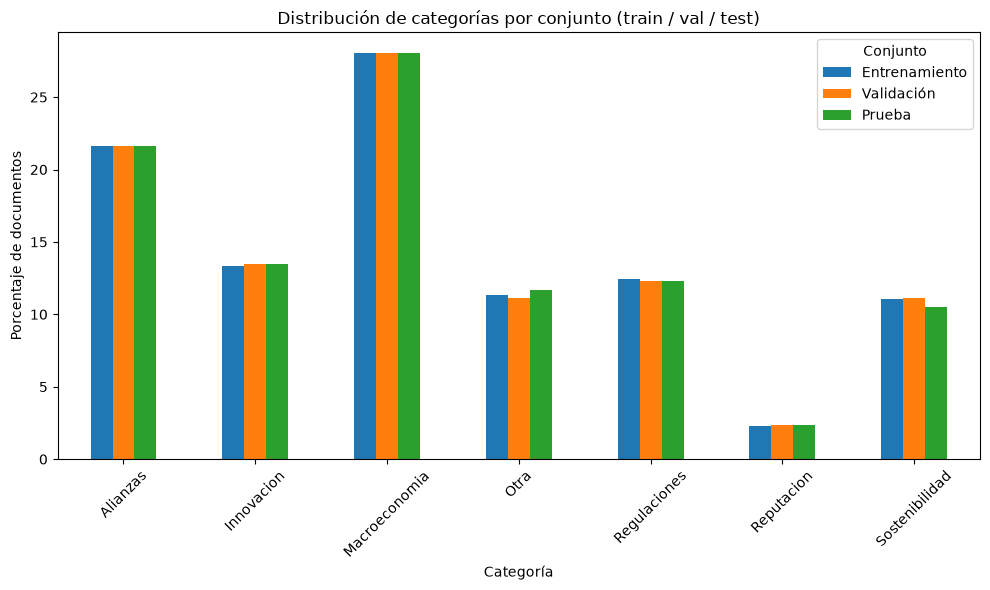

In [29]:
#celda 28
# Gráfico de barras comparando la distribución de categorías en los 3 conjuntos
tabla_distribucion.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Categoría')
plt.ylabel('Porcentaje de documentos')
plt.title('Distribución de categorías por conjunto (train / val / test)')
plt.xticks(rotation=45)
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

**¿Para qué sirve cada conjunto y por qué no se usa el de prueba para tomar decisiones?**

El conjunto de entrenamiento es del que el modelo aprende todo y allí calcula las probabilidades. El de validación se usa para comparar versiones del modelo mientras lo estás desarrollando. por ejemplo, para ver si BoW funciona mejor que TF-IDF o qué tamaño de vocabulario conviene más. 
El de prueba se guarda para el final y se usa una sola vez, para medir el desempeño real con datos que el modelo nunca vio.

Si uno se pone a tomar decisiones basándose en los resultados del conjunto de prueba, deja de ser una medición honesta porque de cierta forma el modelo estaría "aprendiendo" de esos datos también, aunque sea indirectamente.

In [30]:
#celda 29
etiquetas_entrenamiento = df_entrenamiento['Type'].values
etiquetas_validacion = df_validacion['Type'].values
etiquetas_prueba = df_prueba['Type'].values

# Bag of Words
vectorizador_bow_train = CountVectorizer()
matriz_bow_entrenamiento = vectorizador_bow_train.fit_transform(df_entrenamiento['texto_normalizado'])
matriz_bow_validacion = vectorizador_bow_train.transform(df_validacion['texto_normalizado'])
matriz_bow_prueba = vectorizador_bow_train.transform(df_prueba['texto_normalizado'])

# TF-IDF
vectorizador_tfidf_train = TfidfVectorizer()
matriz_tfidf_entrenamiento = vectorizador_tfidf_train.fit_transform(df_entrenamiento['texto_normalizado'])
matriz_tfidf_validacion = vectorizador_tfidf_train.transform(df_validacion['texto_normalizado'])
matriz_tfidf_prueba = vectorizador_tfidf_train.transform(df_prueba['texto_normalizado'])

print(f"Vocabulario BoW (entrenamiento): {matriz_bow_entrenamiento.shape[1]} palabras")
print(f"Vocabulario TF-IDF (entrenamiento): {matriz_tfidf_entrenamiento.shape[1]} palabras")

Vocabulario BoW (entrenamiento): 19157 palabras
Vocabulario TF-IDF (entrenamiento): 19157 palabras


In [31]:
#celda 30
from sklearn.naive_bayes import MultinomialNB

modelo_nb_bow = MultinomialNB()
modelo_nb_bow.fit(matriz_bow_entrenamiento, etiquetas_entrenamiento)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](7,)","[172.,106.,223.,..., 99., 18., 88.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](7,)","[-1.53,-2.02,-1.27,...,-2.08,-3.79,-2.2 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U14](7,)","['Alianzas','Innovacion','Macroeconomia',...,'Regulaciones','Reputacion', 'Sostenibilidad']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](7, 19157)","[[ 1., 9., 0.,...,19., 1., 3.], [ 1., 4., 1.,...,26., 0.,14.], [ 3., 1., 0.,..., 9., 0., 4.], ..., [ 0., 3., 0.,..., 7., 0., 3.], [ 0., 0., 0.,..., 4., 0., 1.], [ 0., 2., 0.,...,16., 0.,13.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](7, 19157)","[[-10.22, -8.61,-10.91,..., -7.91,-10.22, -9.52], [-10.16, -9.25,-10.16,..., -7.56,-10.86, -8.15], [-10. ,-10.69,-11.38,..., -9.08,-11.38, -9.77], ..., [-10.71, -9.32,-10.71,..., -8.63,-10.71, -9.32], [-10.13,-10.13,-10.13,..., -8.52,-10.13, -9.43], [-10.96, -9.86,-10.96,..., -8.13,-10.96, -8.32]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19157


In [32]:
#celda 31
modelo_nb_tfidf = MultinomialNB()
modelo_nb_tfidf.fit(matriz_tfidf_entrenamiento, etiquetas_entrenamiento)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](7,)","[172.,106.,223.,..., 99., 18., 88.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](7,)","[-1.53,-2.02,-1.27,...,-2.08,-3.79,-2.2 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U14](7,)","['Alianzas','Innovacion','Macroeconomia',...,'Regulaciones','Reputacion', 'Sostenibilidad']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](7, 19157)","[[0.05,0.63,0. ,...,0.74,0.1 ,0.1 ], [0.07,0.28,0.04,...,0.74,0. ,0.41], [0.22,0.06,0. ,...,0.3 ,0. ,0.14], ..., [0. ,0.15,0. ,...,0.24,0. ,0.13], [0. ,0. ,0. ,...,0.13,0. ,0.04], [0. ,0.06,0. ,...,0.32,0. ,0.56]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](7, 19157)","[[-9.89,-9.46,-9.95,...,-9.39,-9.85,-9.85], [-9.85,-9.67,-9.88,...,-9.36,-9.92,-9.57], [-9.79,-9.93,-9.99,...,-9.73,-9.99,-9.86], ..., [-9.92,-9.78,-9.92,...,-9.7 ,-9.92,-9.8 ], [-9.87,-9.87,-9.87,...,-9.75,-9.87,-9.83], [-9.92,-9.86,-9.92,...,-9.64,-9.92,-9.47]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19157


**¿Qué representan P(c) y P(wᵢ|c) en este corpus y cómo los combina el modelo para clasificar?**

Se entrenaron dos modelos, uno de ellos fue usando BoW y otro fue usando TF-IDF, los dos ajustando solo los datos de entrenamiento y luego se aplicaan a validación y se prueba con ese mismo vocabulario, para no meter información de más.

P(c) es básicamente qué tan común es cada categoría en el corpus de entrenamiento. Por ejemplo, como Macroeconomia representa el 28% de los documentos de entrenamiento, su P(c) ≈ 0.28. Eso hace que el modelo ya tenga cierta inclinación hacia esa categoría antes de ver el texto.

P(wᵢ|c) es la probabilidad de que aparezca una palabra específica dado que el documento es de cierta categoría, osea, qué tan seguido aparece esa palabra dentro de los documentos de esa clase.

Para clasificar un documento nuevo, el modelo calcula un puntaje por cada categoría multiplicando P(c) por la P(wᵢ|c) de cada palabra del documento (asumiendo que las palabras son independientes entre sí, que es el supuesto "ingenuo"). La categoría con el puntaje más alto gana.

In [33]:
#celda 32
from sklearn.metrics import classification_report, confusion_matrix

predicciones_bow_val = modelo_nb_bow.predict(matriz_bow_validacion)
predicciones_tfidf_val = modelo_nb_tfidf.predict(matriz_tfidf_validacion)

print("BoW  Validación")
print(classification_report(etiquetas_validacion, predicciones_bow_val))
print("TF-IDF  Validación")
print(classification_report(etiquetas_validacion, predicciones_tfidf_val))

BoW  Validación
                precision    recall  f1-score   support

      Alianzas       0.83      0.78      0.81        37
    Innovacion       0.68      1.00      0.81        23
 Macroeconomia       0.82      0.85      0.84        48
          Otra       0.75      0.63      0.69        19
  Regulaciones       0.82      0.67      0.74        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.89      0.84      0.86        19

      accuracy                           0.80       171
     macro avg       0.83      0.72      0.73       171
  weighted avg       0.81      0.80      0.79       171

TF-IDF  Validación
                precision    recall  f1-score   support

      Alianzas       0.65      0.65      0.65        37
    Innovacion       1.00      0.61      0.76        23
 Macroeconomia       0.41      1.00      0.58        48
          Otra       0.00      0.00      0.00        19
  Regulaciones       0.00      0.00      0.00        21
    Reput

/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

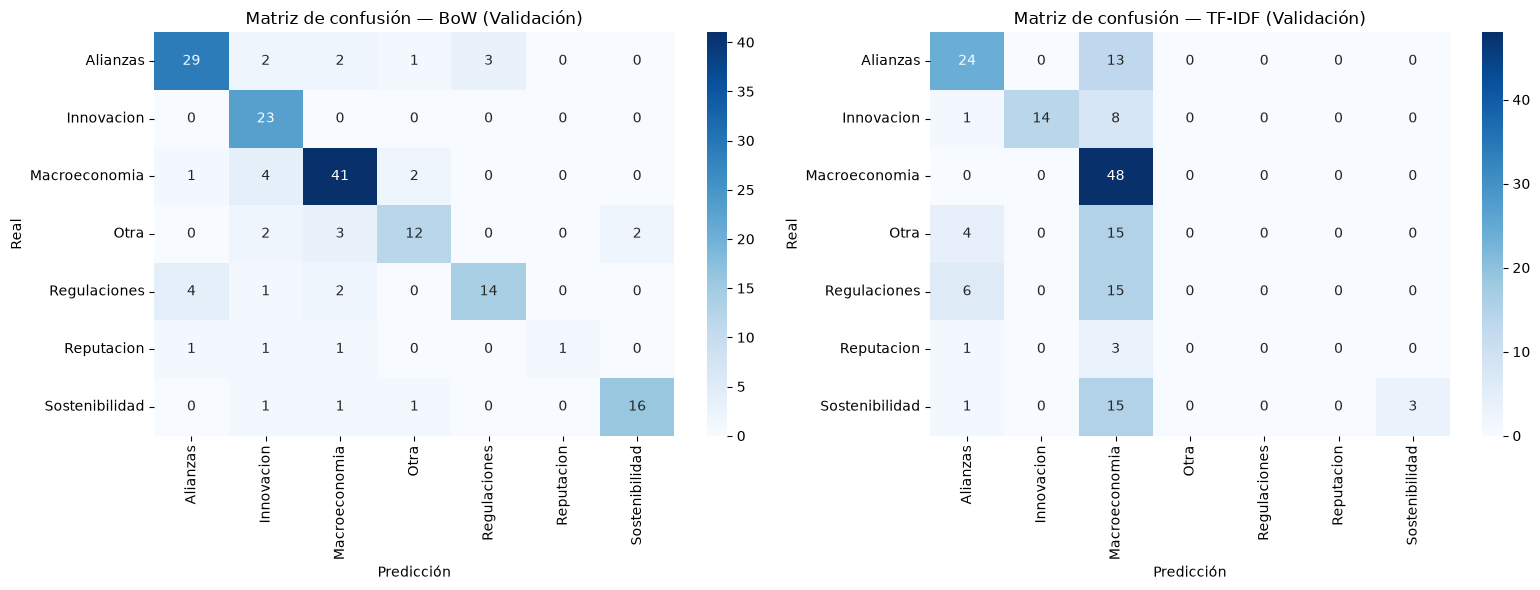

In [34]:
#celda 33
import seaborn as sns

clases_ordenadas = sorted(total_df['Type'].unique())

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

matriz_conf_bow = confusion_matrix(etiquetas_validacion, predicciones_bow_val, labels=clases_ordenadas)
sns.heatmap(matriz_conf_bow, annot=True, fmt='d', cmap='Blues', xticklabels=clases_ordenadas, yticklabels=clases_ordenadas, ax=ejes[0])
ejes[0].set_title('Matriz de confusión — BoW (Validación)')
ejes[0].set_xlabel('Predicción')
ejes[0].set_ylabel('Real')

matriz_conf_tfidf = confusion_matrix(etiquetas_validacion, predicciones_tfidf_val, labels=clases_ordenadas)
sns.heatmap(matriz_conf_tfidf, annot=True, fmt='d', cmap='Blues', xticklabels=clases_ordenadas, yticklabels=clases_ordenadas, ax=ejes[1])
ejes[1].set_title('Matriz de confusión — TF-IDF (Validación)')
ejes[1].set_xlabel('Predicción')
ejes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [35]:
#celda 34
predicciones_bow_prueba = modelo_nb_bow.predict(matriz_bow_prueba)
predicciones_tfidf_prueba = modelo_nb_tfidf.predict(matriz_tfidf_prueba)

print("BoW — Prueba")
print(classification_report(etiquetas_prueba, predicciones_bow_prueba))
print("TF-IDF — Prueba")
print(classification_report(etiquetas_prueba, predicciones_tfidf_prueba))

BoW — Prueba
                precision    recall  f1-score   support

      Alianzas       0.83      0.78      0.81        37
    Innovacion       0.74      1.00      0.85        23
 Macroeconomia       0.88      0.92      0.90        48
          Otra       0.90      0.45      0.60        20
  Regulaciones       0.94      0.76      0.84        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.67      1.00      0.80        18

      accuracy                           0.82       171
     macro avg       0.85      0.74      0.74       171
  weighted avg       0.84      0.82      0.81       171

TF-IDF — Prueba
                precision    recall  f1-score   support

      Alianzas       0.72      0.78      0.75        37
    Innovacion       0.94      0.70      0.80        23
 Macroeconomia       0.43      1.00      0.60        48
          Otra       0.00      0.00      0.00        20
  Regulaciones       0.00      0.00      0.00        21
    Reputacion 

/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [36]:
#celda 35
predicciones_bow_train = modelo_nb_bow.predict(matriz_bow_entrenamiento)
predicciones_tfidf_train = modelo_nb_tfidf.predict(matriz_tfidf_entrenamiento)

reporte_bow_train = classification_report(etiquetas_entrenamiento, predicciones_bow_train, output_dict=True)
reporte_bow_val = classification_report(etiquetas_validacion, predicciones_bow_val, output_dict=True)
reporte_bow_prueba = classification_report(etiquetas_prueba, predicciones_bow_prueba, output_dict=True)

reporte_tfidf_train = classification_report(etiquetas_entrenamiento, predicciones_tfidf_train, output_dict=True)
reporte_tfidf_val = classification_report(etiquetas_validacion, predicciones_tfidf_val, output_dict=True)
reporte_tfidf_prueba = classification_report(etiquetas_prueba, predicciones_tfidf_prueba, output_dict=True)

tabla_overfitting = pd.DataFrame({
    'BoW': [reporte_bow_train['accuracy'], reporte_bow_val['accuracy'], reporte_bow_prueba['accuracy']],
    'TF-IDF': [reporte_tfidf_train['accuracy'], reporte_tfidf_val['accuracy'], reporte_tfidf_prueba['accuracy']]
}, index=['Entrenamiento', 'Validación', 'Prueba'])

tabla_overfitting

/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

,BoW,TF-IDF
Entrenamiento,0.952261,0.692211
Validación,0.795322,0.520468
Prueba,0.818713,0.555556


**¿Hay overfitting? ¿Cuál modelo fue mejor y por qué?**

El modelo con BoW me sacó un accuracy de 0.80 en validación y un 0.82 en prueba (F1 macro 0.74). El modelo con TF-IDF tuvo un muchisimo peor rendimiento, ya que en el accuracy tuvo un resultado de 0.52 en validación y 0.56 en la prueba, con categorías enteras como Otra, Regulaciones y Reputacion con precision y recall en 0, osea el modelo casi nunca las predijo.

Por otro lado, con el BoW tuvo 0.95 de accuracy en entrenamiento y bajó a 0.80-0.82 en validación/prueba. Debido a que tuvo una caida o bajó, se puede llegar a decir y confirmar que si hubo overfitting. Asímismo, esto se puede comprobar ya que, cuando se habla de la caida que tuvo, tiene sentido porque con 19157 palabras de vocabulario y solo 796 documentos de entrenamiento, el modelo aprende patrones muy específicos del train que no necesariamente se repiten en datos nuevos.

El mejor modelo fue BoW, debido a que es por que el TF-IDF baja el peso de palabras que se repiten mucho en el corpus, pero en palabras repetidas muy específicas como es el caso con "empresa", "banco", "mercado" son las que mejor distinguen entre categorías. TF-IDF las penaliza y el modelo pierde esas señales.

In [37]:
#celda 36
class ClasificadorNaiveBayesPropio:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def entrenar(self, matriz_conteos, etiquetas):
        self.clases = np.unique(etiquetas)
        n_documentos, tamaño_vocabulario = matriz_conteos.shape
        self.log_prob_clase = {}
        self.log_prob_palabra_dado_clase = {}

        for clase in self.clases:
            indices_clase = np.where(etiquetas == clase)[0]
            n_documentos_clase = len(indices_clase)
            # P(c): proporción de documentos de esta clase
            self.log_prob_clase[clase] = np.log(n_documentos_clase / n_documentos)

            # Suma de conteos de cada palabra dentro de los documentos de esta clase
            conteos_clase = np.asarray(matriz_conteos[indices_clase].sum(axis=0)).flatten()
            total_palabras_clase = conteos_clase.sum()

            # P(wi|c) con suavizado de Laplace
            self.log_prob_palabra_dado_clase[clase] = np.log(
                (conteos_clase + self.alpha) / (total_palabras_clase + self.alpha * tamaño_vocabulario)
            )
        return self

    def predecir(self, matriz_conteos):
        predicciones = []
        matriz_densa = matriz_conteos.toarray()
        for fila_documento in matriz_densa:
            puntajes_por_clase = {}
            for clase in self.clases:
                puntaje = self.log_prob_clase[clase] + np.sum(fila_documento * self.log_prob_palabra_dado_clase[clase])
                puntajes_por_clase[clase] = puntaje
            predicciones.append(max(puntajes_por_clase, key=puntajes_por_clase.get))
        return np.array(predicciones)


clasificador_propio = ClasificadorNaiveBayesPropio(alpha=1.0)
clasificador_propio.entrenar(matriz_bow_entrenamiento, etiquetas_entrenamiento)

predicciones_propio_prueba = clasificador_propio.predecir(matriz_bow_prueba)

print("Implementación propia")
print(classification_report(etiquetas_prueba, predicciones_propio_prueba))

Implementación propia
                precision    recall  f1-score   support

      Alianzas       0.83      0.78      0.81        37
    Innovacion       0.74      1.00      0.85        23
 Macroeconomia       0.88      0.92      0.90        48
          Otra       0.90      0.45      0.60        20
  Regulaciones       0.94      0.76      0.84        21
    Reputacion       1.00      0.25      0.40         4
Sostenibilidad       0.67      1.00      0.80        18

      accuracy                           0.82       171
     macro avg       0.85      0.74      0.74       171
  weighted avg       0.84      0.82      0.81       171



In [38]:
#celda 37
# Comparación directa: implementación propia vs MultinomialNB de sklearn (ambos con BoW)
reporte_propio = classification_report(etiquetas_prueba, predicciones_propio_prueba, output_dict=True)
reporte_sklearn_bow = classification_report(etiquetas_prueba, predicciones_bow_prueba, output_dict=True)

tabla_comparacion_implementaciones = pd.DataFrame({
    'Accuracy': [reporte_propio['accuracy'], reporte_sklearn_bow['accuracy']],
    'F1 macro': [reporte_propio['macro avg']['f1-score'], reporte_sklearn_bow['macro avg']['f1-score']],
    'F1 ponderado': [reporte_propio['weighted avg']['f1-score'], reporte_sklearn_bow['weighted avg']['f1-score']]
}, index=['Implementación propia', 'MultinomialNB (sklearn)'])

tabla_comparacion_implementaciones

,Accuracy,F1 macro,F1 ponderado
Implementación propia,0.818713,0.742496,0.808096
MultinomialNB (sklearn),0.818713,0.742496,0.808096


In [39]:
#celda 38
# mejor modelo
f1_macro_bow = reporte_bow_prueba['macro avg']['f1-score']
f1_macro_tfidf = reporte_tfidf_prueba['macro avg']['f1-score']

if f1_macro_tfidf > f1_macro_bow:
    predicciones_mejor_modelo = predicciones_tfidf_prueba
    nombre_mejor_modelo = 'TF-IDF'
else:
    predicciones_mejor_modelo = predicciones_bow_prueba
    nombre_mejor_modelo = 'BoW'

print(f"Mejor modelo: {nombre_mejor_modelo}")
print(f"F1 macro BoW: {f1_macro_bow:.4f}")
print(f"F1 macro TF-IDF: {f1_macro_tfidf:.4f}")

# Buscamos el par de categorías con más confusión (fuera de la diagonal)
matriz_conf_mejor_modelo = confusion_matrix(etiquetas_prueba, predicciones_mejor_modelo, labels=clases_ordenadas)
matriz_sin_diagonal = matriz_conf_mejor_modelo.copy()
np.fill_diagonal(matriz_sin_diagonal, 0)

fila_max, columna_max = np.unravel_index(np.argmax(matriz_sin_diagonal), matriz_sin_diagonal.shape)
categoria_real_confundida = clases_ordenadas[fila_max]
categoria_predicha_confundida = clases_ordenadas[columna_max]

print(f"Mas confundido '{categoria_real_confundida}' clasificada como '{categoria_predicha_confundida}'")
print(f"Cantidad de casos: {matriz_sin_diagonal[fila_max, columna_max]}")


Mejor modelo: BoW
F1 macro BoW: 0.7425
F1 macro TF-IDF: 0.3362
Mas confundido 'Otra' clasificada como 'Sostenibilidad'
Cantidad de casos: 4


In [40]:
#celda 39
# 5 documentos mal clasificados
df_prueba_resultado = df_prueba.copy()
df_prueba_resultado['prediccion'] = predicciones_mejor_modelo

documentos_mal_clasificados = df_prueba_resultado[
    (df_prueba_resultado['Type'] == categoria_real_confundida) &
    (df_prueba_resultado['prediccion'] == categoria_predicha_confundida)
]

print(f"Documentos reales de '{categoria_real_confundida}' clasificados como '{categoria_predicha_confundida}': {len(documentos_mal_clasificados)}")
print()
for indice_doc, fila_doc in documentos_mal_clasificados.head(5).iterrows():
    print(f"--- Documento índice {indice_doc} ---")
    print(fila_doc['news'][:300])
    print()

Documentos reales de 'Otra' clasificados como 'Sostenibilidad': 4

--- Documento índice 989 ---
Bbva ha actuado como banco coordinador en la financiación en formato project finance por US3799 millones 320 millones de euros  de Nabiax empresa de data centers en España y América Latina esta operación marca un hito en el sector de la tecnología de datos.Este project finance se convierte en sosten

--- Documento índice 427 ---
Bbva ascendió una posición en el Dow Jones Sustainability Index Djsi y se convirtió en el banco más sostenible del mundo junto a la entidad surcoreana KB Financial Group. Ambos obtuvieron la máxima puntuación dentro de la categoría de bancos a nivel global.La entidad financiera que tenía 88 puntos d

--- Documento índice 697 ---
En el marco del Foro de La banca articuladora empresarial para el desarrollo sostenible organizado por este medio Antoni Ballabriga director de negocio responsable de Bbva dijo que los ODS y los acuerdos de Paris son dos acuerdos marcos para 

In [41]:
#celda 40
categorias_a_revisar = clases_ordenadas[:3]
vocabulario_bow = vectorizador_bow_train.get_feature_names_out()

for categoria in categorias_a_revisar:
    log_probs_categoria = clasificador_propio.log_prob_palabra_dado_clase[categoria]
    indices_top = np.argsort(log_probs_categoria)[::-1][:10]

    print(f"\nTop 10 palabras con mayor P(w|c) — Categoría: {categoria}")
    for indice_palabra in indices_top:
        print(f"  {vocabulario_bow[indice_palabra]}: {np.exp(log_probs_categoria[indice_palabra]):.5f}")


Top 10 palabras con mayor P(w|c) — Categoría: Alianzas
  alianza: 0.00539
  poder: 0.00431
  país: 0.00418
  colombia: 0.00391
  millón: 0.00356
  empresa: 0.00320
  él: 0.00312
  nuevo: 0.00309
  año: 0.00307
  hacer: 0.00280

Top 10 palabras con mayor P(w|c) — Categoría: Innovacion
  bbva: 0.01198
  poder: 0.00593
  él: 0.00505
  banco: 0.00482
  digital: 0.00451
  cliente: 0.00422
  nuevo: 0.00389
  financiero: 0.00353
  permitir: 0.00339
  empresa: 0.00324

Top 10 palabras con mayor P(w|c) — Categoría: Macroeconomia
  inflación: 0.01068
  precio: 0.00799
  año: 0.00793
  poder: 0.00574
  bbva: 0.00438
  él: 0.00419
  mayor: 0.00418
  mes: 0.00399
  tasa: 0.00370
  país: 0.00367


**¿Qué categorías confundió más el modelo y por qué?**

Las categorías que más confundió fue "Otra" y "Sostenibilidad". Ya que, 4 documentos reales de Otra fueron clasificados como "Sostenibilidad". CUando se revisa con mas precisión esos 4 documentos, todos hablan de BBVA y temas de sostenibilidad bancaria, financiamiento sostenible, rankings, foros. Osea que comparten un montón de vocabulario con Sostenibilidad ("sostenible", "sostenibilidad", "banco") aunque técnicamente estén etiquetados como Otra porque el foco de la noticia es otro.

**¿Tienen sentido las palabras con mayor P(wᵢ|c)?**

La mayoría de ellos, sí. Es decir, para Macroeconomia salen palabras como inflación, precio, tasa, mes, que son palabras económicas que si tienen sentido. Para Alianzas la palabra más probable es directamente "alianza", bastante obvio. Para Innovacion en cambio salen cosas como bbva, banco, poder, él, que no son tan representativas del tema innovación sino que son palabras genéricas o nombres de empresa que sobrevivieron los stopwords.

**¿Cómo contribuye el supuesto de independencia a los errores?**

Como el modelo trata cada palabra por separado sin ver el contexto, si "BBVA" aparece en documentos de muchas categorías distintas, el modelo no sabe si ese BBVA está en un contexto de innovación digital o de sostenibilidad. Solo suma las probabilidades individuales de cada palabra. Por lo tanto, eso lo hace fallar y le quita precisión cuando dos categorías comparten vocabulario de marca o palabras genéricas que no son realmente indicativas del tema.

In [42]:
#celda 41
resultados_representaciones = []

# BoW vocabulario completo
resultados_representaciones.append(('BoW - vocabulario completo', matriz_bow_entrenamiento.shape[1], f1_macro_bow_prueba := reporte_bow_prueba['macro avg']['f1-score'], reporte_bow_prueba['accuracy']))

for tamaño_vocab in [1000, 5000]:
    vectorizador_temp = CountVectorizer(max_features=tamaño_vocab)
    matriz_temp_train = vectorizador_temp.fit_transform(df_entrenamiento['texto_normalizado'])
    matriz_temp_prueba = vectorizador_temp.transform(df_prueba['texto_normalizado'])

    modelo_temp = MultinomialNB()
    modelo_temp.fit(matriz_temp_train, etiquetas_entrenamiento)
    predicciones_temp = modelo_temp.predict(matriz_temp_prueba)

    reporte_temp = classification_report(etiquetas_prueba, predicciones_temp, output_dict=True)
    resultados_representaciones.append((f'BoW - max_features={tamaño_vocab}', tamaño_vocab, reporte_temp['macro avg']['f1-score'], reporte_temp['accuracy']))

    print(f"BoW max_features={tamaño_vocab}: accuracy={reporte_temp['accuracy']:.4f}, F1 macro={reporte_temp['macro avg']['f1-score']:.4f}")

BoW max_features=1000: accuracy=0.8655, F1 macro=0.8565
BoW max_features=5000: accuracy=0.8655, F1 macro=0.8691


In [43]:
#celda 42
import time

# BoW con bigramas + unigramas
tiempo_inicio = time.time()
vectorizador_bigramas_train = CountVectorizer(ngram_range=(1, 2))
matriz_bigramas_entrenamiento = vectorizador_bigramas_train.fit_transform(df_entrenamiento['texto_normalizado'])
matriz_bigramas_prueba = vectorizador_bigramas_train.transform(df_prueba['texto_normalizado'])

modelo_bigramas = MultinomialNB()
modelo_bigramas.fit(matriz_bigramas_entrenamiento, etiquetas_entrenamiento)
tiempo_entrenamiento_bigramas = time.time() - tiempo_inicio

predicciones_bigramas = modelo_bigramas.predict(matriz_bigramas_prueba)
reporte_bigramas = classification_report(etiquetas_prueba, predicciones_bigramas, output_dict=True)

resultados_representaciones.append(('BoW - unigramas + bigramas', matriz_bigramas_entrenamiento.shape[1], reporte_bigramas['macro avg']['f1-score'], reporte_bigramas['accuracy']))

print(f"Vocabulario unigramas+bigramas: {matriz_bigramas_entrenamiento.shape[1]} términos")
print(f"Tiempo de entrenamiento: {tiempo_entrenamiento_bigramas:.2f} segundos")
print(f"Accuracy: {reporte_bigramas['accuracy']:.4f}")
print(f"F1 macro: {reporte_bigramas['macro avg']['f1-score']:.4f}")

Vocabulario unigramas+bigramas: 185042 términos
Tiempo de entrenamiento: 0.32 segundos
Accuracy: 0.7719
F1 macro: 0.6773


In [44]:
#celda 43
resultados_representaciones.append(('TF-IDF - vocabulario completo', matriz_tfidf_entrenamiento.shape[1], f1_macro_tfidf, reporte_tfidf_prueba['accuracy']))
resultados_representaciones.append(('Implementación propia (BoW)', matriz_bow_entrenamiento.shape[1], reporte_propio['macro avg']['f1-score'], reporte_propio['accuracy']))

tabla_comparativa_final = pd.DataFrame(resultados_representaciones, columns=['Representación', 'Tamaño de vocabulario', 'F1 macro', 'Accuracy'])
tabla_comparativa_final = tabla_comparativa_final.sort_values('F1 macro', ascending=False).reset_index(drop=True)
tabla_comparativa_final

,Representación,Tamaño de vocabulario,F1 macro,Accuracy
0,BoW - max_features=5000,5000,0.869052,0.865497
1,BoW - max_features=1000,1000,0.856502,0.865497
2,BoW - vocabulario completo,19157,0.742496,0.818713
3,Implementación propia (BoW),19157,0.742496,0.818713
4,BoW - unigramas + bigramas,185042,0.677272,0.771930
5,TF-IDF - vocabulario completo,19157,0.336178,0.555556


**¿Cómo afecta limitar el vocabulario y usar bigramas?**

Cuando se limita el vocabulario a 1000 palabras el modelo sacó accuracy 0.8655 y F1 macro 0.8565. Luego cuando se limitó a 5000 palabras, el accuracy qudó igual pero F1 macro sube a 0.8691. Ambos le ganan al vocabulario completo de 19157 palabras. 
Tiene sentido porque con solo 796 documentos de entrenamiento y casi 20 mil palabras, muchas palabras aparecen muy pocas veces y sus probabilidades son poco confiables. Al quedarse solo con las más frecuentes, las estimaciones son más estables.
Con bigramas el vocabulario incrementó por muchisimo y pasó de 19157 a 185042 términos y el desempeño empeoró considerablemente a comparación de cuando lo limitamos con un accuracy de 0.7719 y un F1 macro de 0.6773. Por ende, más vocabulario no necesariamente significa mejor modelo, y con tan pocos documentos de entrenamiento cada bigrama aparece tan pocas veces que sus probabilidades son más ruido que señal.

**Tabla comparativa de todos los modelos:**

| Representación | Vocabulario | F1 macro | Accuracy |
|---|---:|---:|---:|
| BoW - max_features=5000 | 5000 | 0.8691 | 0.8655 |
| BoW - max_features=1000 | 1000 | 0.8565 | 0.8655 |
| BoW - vocabulario completo | 19157 | 0.7425 | 0.8187 |
| Implementación propia (BoW) | 19157 | 0.7425 | 0.8187 |
| BoW - unigramas + bigramas | 185042 | 0.6773 | 0.7719 |
| TF-IDF - vocabulario completo | 19157 | 0.3362 | 0.5556 |

**¿Qué pasó con la implementación propia?**

Se programó Naive Bayes desde cero calculando P(c), P(wᵢ|c) con suavizado de Laplace y usando logaritmos para evitar el problema de multiplicar muchas probabilidades pequeñas. Los resultados fueron exactamente iguales a MultinomialNB de sklearn (accuracy 0.8187, F1 macro 0.7425, idénticos hasta el último decimal), lo que confirma que el cálculo está bien hecho.

# Laboratorio 4: Modelos Lineales

In [ ]:
#celda 44
import time
from sklearn.linear_model import LogisticRegression

# Regresión Logística con BoW
tiempo_inicio_rl_bow = time.time()
modelo_rl_bow = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
modelo_rl_bow.fit(matriz_bow_entrenamiento, etiquetas_entrenamiento)
tiempo_rl_bow = time.time() - tiempo_inicio_rl_bow

# Regresión Logística con TF-IDF
tiempo_inicio_rl_tfidf = time.time()
modelo_rl_tfidf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
modelo_rl_tfidf.fit(matriz_tfidf_entrenamiento, etiquetas_entrenamiento)
tiempo_rl_tfidf = time.time() - tiempo_inicio_rl_tfidf

print(f"RL con BoW entrenado en {tiempo_rl_bow:.2f} seg")
print(f"RL con TF-IDF entrenado en {tiempo_rl_tfidf:.2f} seg")

RL con BoW entrenado en 0.33 segundos
RL con TF-IDF entrenado en 0.18 segundos


**Explique con sus propias palabras qué representan z = w·x + b y la función sigmoide σ(z) = 1/(1+e-z) en este contexto, y cómo se convierte ese puntaje en una probabilidad y luego en una predicción de clase.**

En regresión logística, (z = w \cdot x + b) representa basicamente el puntaje que el modelo calcula para una clase específica a partir de las características que el documento tiene. Por ejemplo, ahorita en este caso "x" es la representación vectorial de la noticia, ya sea con BoW o TF-IDF. Por otro lado, "W" es los pesos que el modelo aprende para cada palabra y la variable "b" es el intercepto del modelo.

Un peso positivo hace que la presencia de una palabra aumente el puntaje de una categoría, mientras que un peso negativo hace que disminuya. Por ejemplo, si una palabra está fuertemente relacionada con Macroeconomia, el modelo puede aprender un peso positivo alto para esa palabra dentro de esa categoría.

En un problema binario, la función sigmoide (\sigma(z)=1/(1+e^{-z})) transforma el puntaje (z) en un valor entre 0 y 1 que puede interpretarse como probabilidad. Sin embargo, este corpus tiene 7 categorías, por lo que el modelo calcula un puntaje para cada una y, en el caso multiclase utilizado por LogisticRegression, estos puntajes se convierten en probabilidades entre las distintas clases. Finalmente, se selecciona como predicción la categoría que obtiene la probabilidad más alta.

In [ ]:
#celda 45
# Evaluación de validación
predicciones_rl_bow_val = modelo_rl_bow.predict(matriz_bow_validacion)
predicciones_rl_tfidf_val = modelo_rl_tfidf.predict(matriz_tfidf_validacion)

print("RL BoW Validación")
print(classification_report(etiquetas_validacion, predicciones_rl_bow_val))
print("RL TF-IDF Validación")
print(classification_report(etiquetas_validacion, predicciones_rl_tfidf_val))

RL BoW — Validación
                precision    recall  f1-score   support

      Alianzas       0.84      1.00      0.91        37
    Innovacion       0.81      0.96      0.88        23
 Macroeconomia       0.89      0.85      0.87        48
          Otra       0.78      0.74      0.76        19
  Regulaciones       1.00      0.81      0.89        21
    Reputacion       1.00      0.50      0.67         4
Sostenibilidad       0.88      0.79      0.83        19

      accuracy                           0.87       171
     macro avg       0.89      0.81      0.83       171
  weighted avg       0.87      0.87      0.86       171

RL TF-IDF — Validación
                precision    recall  f1-score   support

      Alianzas       0.75      0.97      0.85        37
    Innovacion       0.79      1.00      0.88        23
 Macroeconomia       0.86      0.90      0.88        48
          Otra       0.87      0.68      0.76        19
  Regulaciones       1.00      0.76      0.86        21
 

/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [ ]:
#celda 46
# Evaluación de prueba
predicciones_rl_bow_prueba = modelo_rl_bow.predict(matriz_bow_prueba)
predicciones_rl_tfidf_prueba = modelo_rl_tfidf.predict(matriz_tfidf_prueba)

print("RL BoW Prueba")
print(classification_report(etiquetas_prueba, predicciones_rl_bow_prueba))
print("RL TF-IDF Prueba")
print(classification_report(etiquetas_prueba, predicciones_rl_tfidf_prueba))

RL BoW — Prueba
                precision    recall  f1-score   support

      Alianzas       0.87      0.92      0.89        37
    Innovacion       0.95      0.83      0.88        23
 Macroeconomia       0.94      0.94      0.94        48
          Otra       0.79      0.75      0.77        20
  Regulaciones       0.95      0.86      0.90        21
    Reputacion       1.00      0.75      0.86         4
Sostenibilidad       0.65      0.83      0.73        18

      accuracy                           0.87       171
     macro avg       0.88      0.84      0.85       171
  weighted avg       0.88      0.87      0.87       171

RL TF-IDF — Prueba
                precision    recall  f1-score   support

      Alianzas       0.64      0.92      0.76        37
    Innovacion       0.84      0.91      0.88        23
 Macroeconomia       0.94      0.92      0.93        48
          Otra       0.83      0.25      0.38        20
  Regulaciones       0.94      0.76      0.84        21
    Reput

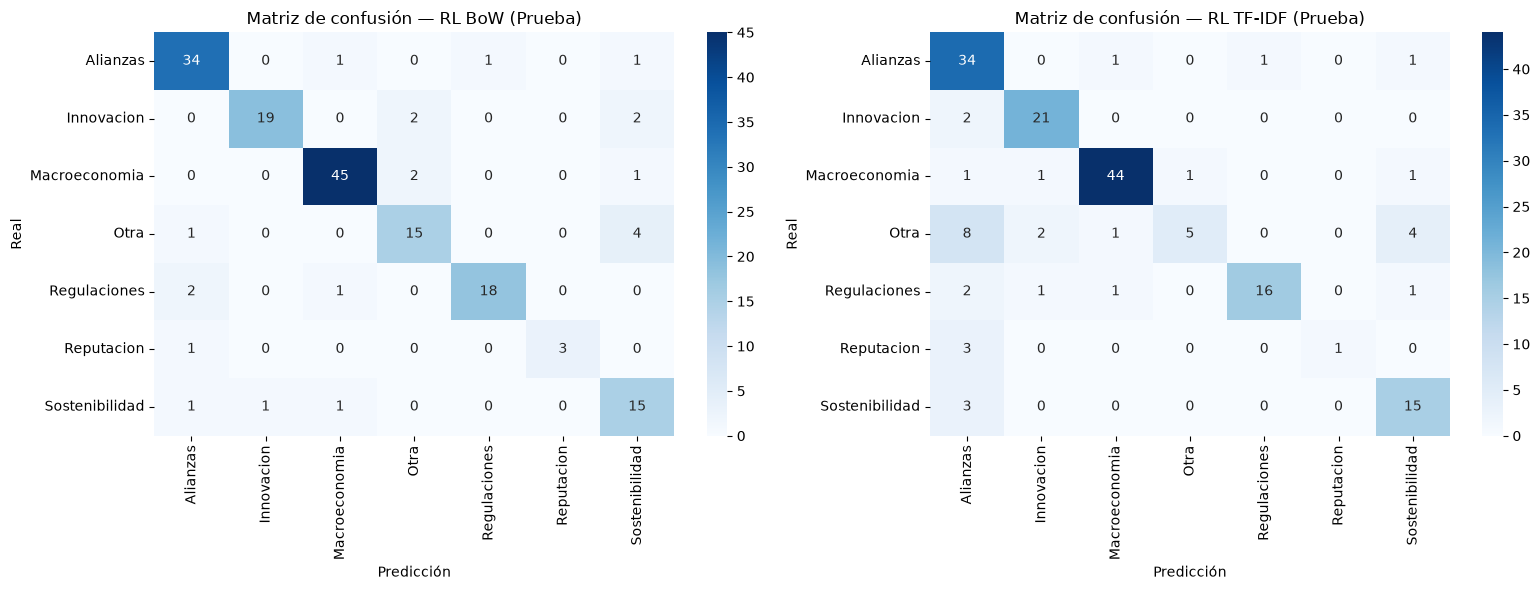

In [ ]:
#celda 47
# Matrices de confusión de los 2 modelos de prueba
fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

matriz_conf_rl_bow = confusion_matrix(etiquetas_prueba, predicciones_rl_bow_prueba, labels=clases_ordenadas)
sns.heatmap(matriz_conf_rl_bow, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases_ordenadas, yticklabels=clases_ordenadas, ax=ejes[0])
ejes[0].set_title('Matriz de confusión RL BoW')
ejes[0].set_xlabel('Predicción')
ejes[0].set_ylabel('Real')

matriz_conf_rl_tfidf = confusion_matrix(etiquetas_prueba, predicciones_rl_tfidf_prueba, labels=clases_ordenadas)
sns.heatmap(matriz_conf_rl_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases_ordenadas, yticklabels=clases_ordenadas, ax=ejes[1])
ejes[1].set_title('Matriz de confusión RL TF-IDF')
ejes[1].set_xlabel('Predicción')
ejes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [ ]:
#celda 48
# Comparación train vs validación vs prueba
predicciones_rl_bow_train = modelo_rl_bow.predict(matriz_bow_entrenamiento)
predicciones_rl_tfidf_train = modelo_rl_tfidf.predict(matriz_tfidf_entrenamiento)

reporte_rl_bow_train = classification_report(etiquetas_entrenamiento, predicciones_rl_bow_train, output_dict=True)
reporte_rl_bow_val = classification_report(etiquetas_validacion, predicciones_rl_bow_val, output_dict=True)
reporte_rl_bow_prueba = classification_report(etiquetas_prueba, predicciones_rl_bow_prueba, output_dict=True)

reporte_rl_tfidf_train = classification_report(etiquetas_entrenamiento, predicciones_rl_tfidf_train, output_dict=True)
reporte_rl_tfidf_val = classification_report(etiquetas_validacion, predicciones_rl_tfidf_val, output_dict=True)
reporte_rl_tfidf_prueba = classification_report(etiquetas_prueba, predicciones_rl_tfidf_prueba, output_dict=True)

tabla_overfitting_rl = pd.DataFrame({
    'RL BoW': [reporte_rl_bow_train['accuracy'], reporte_rl_bow_val['accuracy'], reporte_rl_bow_prueba['accuracy']],
    'RL TF-IDF': [reporte_rl_tfidf_train['accuracy'], reporte_rl_tfidf_val['accuracy'], reporte_rl_tfidf_prueba['accuracy']]
}, index=['Entrenamiento', 'Validación', 'Prueba'])

tabla_overfitting_rl

/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luispegr25/Documents/UNIVERSIDAD/8vo Semestre/NLP/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

,RL BoW,RL TF-IDF
Entrenamiento,1.000000,0.962312
Validación,0.865497,0.842105
Prueba,0.871345,0.795322


**Compare el desempeño en entrenamiento contra el desempeño en validación/prueba. ¿Hay
indicios de overfitting? Relacione su respuesta con lo visto en clase sobre generalización.**

**Indique cuál de las dos representaciones (BoW o TF-IDF) obtuvo mejor desempeño con regresión
logística y proponga una explicación.**

La regresión logística tuvo un mejor resultado y trabajo utilizando BoW que utilizando TF-IDF. Asi como se puede ver en la tabla que está justo abajo:

| Representación | Conjunto   | Accuracy | Precision macro | Recall macro | F1 macro | F1 ponderado |
| -------------- | ---------- | -------: | --------------: | -----------: | -------: | -----------: |
| BoW            | Validación |   0.8655 |            0.89 |         0.81 |     0.83 |         0.86 |
| BoW            | Prueba     |   0.8713 |            0.88 |         0.84 |     0.85 |         0.87 |
| TF-IDF         | Validación |   0.8421 |            0.75 |         0.71 |     0.72 |         0.83 |
| TF-IDF         | Prueba     |   0.7953 |            0.84 |         0.69 |     0.70 |         0.78 |

Ahora bien, analizando y hablando sobre el overfitting, sí se puede llegar a notar que hay en ambos modelos. Con BoW, el accuracy de entrenamiento fue de 1.00, mientras que en validación bajó a 0.8655 y en prueba a 0.8713. Esto significa que el modelo clasificó bastante bien los datos que utilizó para aprender, pero perdió aproximadamente 13% cuando recibió documentos nuevos.

Con TF-IDF también está esta diferencia obtuvo un accuracy de 0.9623 en entrenamiento, 0.8421 en validación y 0.7953 en prueba. En este caso la caída es todavía mayor al comparar entrenamiento con prueba. Por lo tanto, los modelos aprendieron parcialmente patrones muy específicos del conjunto de entrenamiento que no generalizan de la misma manera a datos nuevos.

Sin embargo, cuando vemos el BoW, se puede notar una mejor capacidad de generalización porque los resultados de validación y prueba son bastante parecidos, e incluso el accuracy mejora un poco y pasa de 0.8655 a 0.8713.

La mejor representación para regresión logística fue BOW ya que tiene un accuracy de 0.8713 y un F1 macro de 0.8534 en prueba, y comparandolo con a 0.7953 de accuracy y 0.7048 de F1 macro del TF-IDF.

Entonces se podría decir que por el tipo de sdatos que tiene este corpus y la frecuencia absoluta de ciertas palabras contiene información importante para separar las categorías. ENtonces TF-IDF reduce la importancia de términos que aparecen con frecuencia en muchos documentos, mientras que BoW conserva sus conteos. Para este conjunto de noticias, parece que esa frecuencia aporta información útil al modelo.

In [ ]:
#celda 49
# mejor modelo de RL según F1
f1_macro_rl_bow = reporte_rl_bow_prueba['macro avg']['f1-score']
f1_macro_rl_tfidf = reporte_rl_tfidf_prueba['macro avg']['f1-score']

if f1_macro_rl_tfidf > f1_macro_rl_bow:
    mejor_modelo_rl = modelo_rl_tfidf
    nombre_mejor_rl = 'TF-IDF'
    vocabulario_mejor_rl = vectorizador_tfidf_train.get_feature_names_out()
else:
    mejor_modelo_rl = modelo_rl_bow
    nombre_mejor_rl = 'BoW'
    vocabulario_mejor_rl = vectorizador_bow_train.get_feature_names_out()

print(f"Mejor modelo RL: {nombre_mejor_rl}")
print(f"F1 macro RL BoW: {f1_macro_rl_bow:.4f}")
print(f"F1 macro RL TF-IDF: {f1_macro_rl_tfidf:.4f}")

Mejor modelo RL: BoW
F1 macro RL BoW: 0.8534
F1 macro RL TF-IDF: 0.7048


In [ ]:
#celda 50
# top 15 mayor peso positivo y negativo
categorias_a_analizar = ['Alianzas', 'Innovacion', 'Macroeconomia']

for categoria in categorias_a_analizar:
    indice_clase = list(mejor_modelo_rl.classes_).index(categoria)
    coeficientes_categoria = mejor_modelo_rl.coef_[indice_clase]

    indices_top_positivos = np.argsort(coeficientes_categoria)[::-1][:15]
    indices_top_negativos = np.argsort(coeficientes_categoria)[:15]

    print(f"\n{'='*50}")
    print(f"Categoría: {categoria}")
    print(f"\nTop 15 palabras con mayor peso positivo:")
    for idx in indices_top_positivos:
        print(f"  {vocabulario_mejor_rl[idx]}: {coeficientes_categoria[idx]:.4f}")

    print(f"\nTop 15 palabras con mayor peso negativo:")
    for idx in indices_top_negativos:
        print(f"  {vocabulario_mejor_rl[idx]}: {coeficientes_categoria[idx]:.4f}")


Categoría: Alianzas

Top 15 palabras con mayor peso positivo:
  alianza: 1.0131
  colombia: 0.3034
  compañía: 0.2962
  acuerdo: 0.2248
  la: 0.2219
  acceso: 0.2194
  anunciar: 0.2075
  político: 0.2037
  colombiano: 0.1980
  programa: 0.1927
  aliado: 0.1891
  presidente: 0.1814
  medio: 0.1814
  en: 0.1807
  marca: 0.1798

Top 15 palabras con mayor peso negativo:
  bbva: -0.7287
  regulación: -0.2575
  reputación: -0.1722
  si: -0.1411
  sistema: -0.1392
  responsable: -0.1258
  podcast: -0.1243
  comisión: -0.1226
  uber: -0.1139
  trabajo: -0.1135
  mayor: -0.1113
  importante: -0.1109
  inversionista: -0.1099
  activo: -0.1099
  españa: -0.1082

Categoría: Innovacion

Top 15 palabras con mayor peso positivo:
  bbva: 0.5734
  podcast: 0.2577
  capital: 0.2301
  importante: 0.2298
  pago: 0.2041
  talento: 0.2036
  summit: 0.1937
  tecnología: 0.1937
  agile: 0.1930
  compartir: 0.1908
  teléfono: 0.1835
  seguridad: 0.1824
  permitir: 0.1775
  design: 0.1771
  emprendimiento: 0.1

**¿Tienen sentido esas palabras como evidencia a favor o en contra de cada categoría?**

**Compare estas palabras con las de mayor P(wi|c) (verosimilitud) obtenidas con Naive Bayes en el Laboratorio #3 para las mismas categorías. ¿Coinciden en su mayoría? ¿Qué diferencias encuentra y a qué las atribuye?**

En Alianzas las palabras con mayor peso positivo si tienen bastante sentido. Ya que la palabra alianza viene acompañada por términos como acuerdo, aliado, programa, compañía y anunciar lo cual si son palabras que vienen del mismo tema. Estas palabras están relacionadas con acuerdos o relaciones entre organizaciones. Entre los pesos negativos aparecen palabras como regulación, reputación y comisión, que pueden estar más asociadas con otras categorías. Tiene un peso de -0.7287, lo cual demuestra que una palabra muy frecuente en el corpus no necesariamente nos sirve como evidencia a favor de todas las categorías.

En Innovacion aparecen con peso positivo palabras como tecnología, agile, design, emprendimiento, pago, teléfono, seguridad y talento, que sí tienen una relación clara con innovación y transformación tecnológica. En cambio, palabras como sostenible y alianza presentan pesos negativos, indicando que su presencia tiende a aportar evidencia hacia otras categorías. También aparecen palabras poco informativas como la, el y en, lo que indica que todavía existe algo de ruido en el vocabulario después del procesamiento.

Para Macroeconomia los resultados están mas faciles de interpretar ya que entre los mayores pesos positivos están: inflación, precio, aumento, economista, ipc, economía, crecimiento e incremento. Todas estas palabras son palabras que están relacionadas con temas macroeconómicos. Por el contrario, términos como digital, usuario, alianza, empresa y compañía tienen pesos negativos y aportan evidencia que son contradictorios o inversos de esta categoría.

Al comparar estos resultados con las palabras de mayor obtenidas con Naive Bayes, se puede notar que no coinciden del todo. Por ejemplo, en Alianzas coinciden principalmente alianza y colombia, en Innovacion coinciden bbva y permitir, y en Macroeconomia coinciden palabras como inflación, precio, año y bbva.

Naive Bayes tenía entre sus palabras principales varios términos muy frecuentes y poco específicos, como poder, él, país, empresa o banco. Esto pasa porque (P(w_i|c)) mide qué tan frecuente es una palabra dentro de una categoría. La regresión logística, aprende los pesos de todas las características en conjunto y intenta separar las categorías. Por eso puede darle más importancia a palabras que realmente ayudan a distinguir una clase de las demás y asignar pesos negativos a palabras que funcionan como evidencia en contra.

In [ ]:
#celda 51
# Tiempos aproximados de NB 
tiempo_inicio_nb_bow = time.time()
modelo_nb_bow.fit(matriz_bow_entrenamiento, etiquetas_entrenamiento)
tiempo_nb_bow = time.time() - tiempo_inicio_nb_bow

tiempo_inicio_nb_tfidf = time.time()
modelo_nb_tfidf.fit(matriz_tfidf_entrenamiento, etiquetas_entrenamiento)
tiempo_nb_tfidf = time.time() - tiempo_inicio_nb_tfidf

# Tabla comparativa de las 4 combinaciones
tabla_comparativa_modelos = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Naive Bayes', 'Regresión Logística', 'Regresión Logística'],
    'Representación': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF'],
    'Accuracy': [
        reporte_bow_prueba['accuracy'],
        reporte_tfidf_prueba['accuracy'],
        reporte_rl_bow_prueba['accuracy'],
        reporte_rl_tfidf_prueba['accuracy']
    ],
    'F1 macro': [
        reporte_bow_prueba['macro avg']['f1-score'],
        reporte_tfidf_prueba['macro avg']['f1-score'],
        reporte_rl_bow_prueba['macro avg']['f1-score'],
        reporte_rl_tfidf_prueba['macro avg']['f1-score']
    ],
    'F1 ponderado': [
        reporte_bow_prueba['weighted avg']['f1-score'],
        reporte_tfidf_prueba['weighted avg']['f1-score'],
        reporte_rl_bow_prueba['weighted avg']['f1-score'],
        reporte_rl_tfidf_prueba['weighted avg']['f1-score']
    ],
    'Tiempo (s)': [
        round(tiempo_nb_bow, 4),
        round(tiempo_nb_tfidf, 4),
        round(tiempo_rl_bow, 4),
        round(tiempo_rl_tfidf, 4)
    ]
})

tabla_comparativa_modelos

,Modelo,Representación,Accuracy,F1 macro,F1 ponderado,Tiempo (s)
0,Naive Bayes,BoW,0.818713,0.742496,0.808096,0.0023
1,Naive Bayes,TF-IDF,0.555556,0.336178,0.460059,0.0020
2,Regresión Logística,BoW,0.871345,0.853434,0.873186,0.3314
3,Regresión Logística,TF-IDF,0.795322,0.704799,0.777896,0.1834


**¿Qué modelo obtuvo mejor desempeño en general sobre el conjunto de prueba? ¿La diferencia es grande o marginal?**

**Relacione la diferencia (o similitud) de desempeño con la forma en que cada modelo calcula sus pesos: estimación aislada de P(wi|c) bajo independencia condicional en Naive Bayes, frente a optimización conjunta de todos los pesos en regresión logística**


Los resultados de los cuatro modelos fueron estos:

| Modelo              | Representación |   Accuracy |   F1 macro | F1 ponderado | Tiempo aprox. |
| ------------------- | -------------- | ---------: | ---------: | -----------: | ------------: |
| Naive Bayes         | BoW            |     0.8187 |     0.7425 |       0.8081 |      0.0023 s |
| Naive Bayes         | TF-IDF         |     0.5556 |     0.3362 |       0.4601 |      0.0020 s |
| Regresión Logística | BoW        |     0.8713 |    0.8534 |      0.8732  |      0.3314 s |
| Regresión Logística | TF-IDF         |     0.7953 |     0.7048 |       0.7779 |      0.1834 s |

EL mejor modelo considerando todos los resultados en conjunto, se puede decir que fue el de la Regresión Logística con BoW. Comparándolo con Naive Bayes con BoW, el accuracy subió de 0.8187 a 0.8713. Por otro lado, no solo el accuracy subió sino tambien tuvo un aumento considerable el F1 macro 0.7425 a 0.8534.

Por lo tanto, no considero que la diferencia sea enorme en cuanto al accuracy honestamente, pero tampoco es marginal. Es una mejora considerable y especialmente porque el F1 macro aumenta más de 0.11, lo cual indica que la regresión logística también está manejando mejor las diferentes categorías y no solamente las clases con mayor cantidad de documentos.

La diferencia entre los modelos puede relacionarse con su forma en la que hace el aprendizaje. Ya que, con Naive Bayes estima (P(w_i|c)) para cada palabra de manera independiente y luego combina esas probabilidades bajo el supuesto de independencia condicional. Esto funciona muy rápido pero no optimiza directamente qué combinación de palabras separa mejor las categorías.

POr otro lado, en regresión logística, aprende todos los pesos conjuntamente buscando directamente una separación entre las clases. De esta manera puede aumentar el peso de características realmente discriminativas y reducir o incluso volver negativo el peso de palabras que aparecen frecuentemente pero que no ayudan a distinguir una categoría.

Esto parece haber sido importante en este corpus, donde muchas noticias comparten vocabulario relacionado con bancos, empresas, países y temas financieros. La regresión logística logró manejar mejor ese vocabulario compartido, aunque necesitó bastante más tiempo de entrenamiento que Naive Bayes.

In [ ]:
#celda 52
# categorías más confundido en el mejor modelo
if f1_macro_rl_tfidf > f1_macro_rl_bow:
    predicciones_rl_mejor_prueba = predicciones_rl_tfidf_prueba
    matriz_conf_rl_mejor = matriz_conf_rl_tfidf
else:
    predicciones_rl_mejor_prueba = predicciones_rl_bow_prueba
    matriz_conf_rl_mejor = matriz_conf_rl_bow

matriz_rl_sin_diagonal = matriz_conf_rl_mejor.copy()
np.fill_diagonal(matriz_rl_sin_diagonal, 0)

fila_max_rl, col_max_rl = np.unravel_index(np.argmax(matriz_rl_sin_diagonal), matriz_rl_sin_diagonal.shape)
categoria_real_rl = clases_ordenadas[fila_max_rl]
categoria_predicha_rl = clases_ordenadas[col_max_rl]

print(f"Par más confundido: '{categoria_real_rl}' clasificada como '{categoria_predicha_rl}'")
print(f"Cantidad de casos: {matriz_rl_sin_diagonal[fila_max_rl, col_max_rl]}")

Par más confundido: 'Otra' clasificada como 'Sostenibilidad'
Cantidad de casos: 4


In [ ]:
#celda 53
# Documentos mal clasificados de ese par
df_prueba_rl = df_prueba.copy()
df_prueba_rl['prediccion_rl'] = predicciones_rl_mejor_prueba

documentos_error_rl = df_prueba_rl[
    (df_prueba_rl['Type'] == categoria_real_rl) &
    (df_prueba_rl['prediccion_rl'] == categoria_predicha_rl)
]

print(f"Documentos reales de '{categoria_real_rl}' clasificados como '{categoria_predicha_rl}': {len(documentos_error_rl)}")
print()
for idx, fila in documentos_error_rl.head(5).iterrows():
    print(f"--- Documento indx {idx} ---")
    print(fila['news'][:300])
    print()

Documentos reales de 'Otra' clasificados como 'Sostenibilidad': 4

--- Documento índice 989 ---
Bbva ha actuado como banco coordinador en la financiación en formato project finance por US3799 millones 320 millones de euros  de Nabiax empresa de data centers en España y América Latina esta operación marca un hito en el sector de la tecnología de datos.Este project finance se convierte en sosten

--- Documento índice 427 ---
Bbva ascendió una posición en el Dow Jones Sustainability Index Djsi y se convirtió en el banco más sostenible del mundo junto a la entidad surcoreana KB Financial Group. Ambos obtuvieron la máxima puntuación dentro de la categoría de bancos a nivel global.La entidad financiera que tenía 88 puntos d

--- Documento índice 697 ---
En el marco del Foro de La banca articuladora empresarial para el desarrollo sostenible organizado por este medio Antoni Ballabriga director de negocio responsable de Bbva dijo que los ODS y los acuerdos de Paris son dos acuerdos marcos para 

In [ ]:
#celda 54
# Comparación entre los modelos y si se confunden en los mismos o no
indices_error_rl = set(documentos_error_rl.head(5).index)

df_prueba_nb = df_prueba.copy()
df_prueba_nb['prediccion_nb'] = predicciones_mejor_modelo 

documentos_error_nb = df_prueba_nb[
    (df_prueba_nb['Type'] == categoria_real_rl) &
    (df_prueba_nb['prediccion_nb'] == categoria_predicha_rl)
]

indices_error_nb = set(documentos_error_nb.index)
indices_comunes = indices_error_rl & indices_error_nb

print(f"Documentos que RL confunde: {sorted(indices_error_rl)}")
print(f"Documentos que NB confundía: {sorted(indices_error_nb)}")
print(f"Documentos en común: {sorted(indices_comunes)}")

Documentos que RL confunde: [0, 427, 697, 989]
Documentos que NB confundía: [0, 427, 697, 989]
Documentos en común: [0, 427, 697, 989]


¿Son los mismos documentos, documentos distintos, o el mismo tipo de confusión?

Relacione al menos un error encontrado con el supuesto de independencia condicional de Naive Bayes frente a la capacidad de la regresión logística de ponderar conjuntamente características correlacionadas.

La confusión que más se repitió en el modelo de regresión logística fue entre las categorías Otra y Sostenibilidad. En total, hubo 4 documentos que realmente pertenecían a Otra, pero el modelo los clasificó como Sostenibilidad.

Al revisar estos documentos, se puede entender por qué ocurrió el error. Por ejemplo, el documento 989 habla de financiamiento de BBVA y menciona que un proyecto se convierte en sostenible. El documento 427 habla del Dow Jones Sustainability Index y de BBVA como uno de los bancos más sostenibles del mundo. El documento 697 menciona temas como desarrollo sostenible, los ODS y los acuerdos de París. Por último, el documento 0 también utiliza varias veces palabras relacionadas con sostenibilidad.

Entonces, aunque estos documentos estén clasificados originalmente como Otra, contienen muchas palabras que normalmente esperaríamos encontrar en la categoría Sostenibilidad. Términos como sostenibilidad, sostenible, ODS y desarrollo probablemente influyeron bastante en la predicción del modelo. Esto muestra que algunas noticias no son tan fáciles de separar, ya que pueden tocar temas de más de una categoría al mismo tiempo.

Al comparar estos errores con Naive Bayes, encontré que los cuatro documentos son exactamente los mismos en ambos modelos: 0, 427, 697 y 989. Es decir, los dos modelos tuvieron el mismo tipo de confusión y además se equivocaron en las mismas noticias.

Esto hace pensar que el problema no viene solamente del modelo utilizado. En realidad, estos documentos tienen bastante contenido relacionado con sostenibilidad, aunque estén etiquetados como Otra, por lo que la diferencia entre ambas categorías no siempre es tan clara.

También se puede relacionar este caso con la forma en que trabajan los dos modelos. Naive Bayes analiza la evidencia de cada palabra bajo el supuesto de independencia condicional. Por ejemplo, si aparecen juntas palabras como sostenible, sostenibilidad, ODS y desarrollo, cada una puede aportar evidencia hacia la categoría Sostenibilidad, aunque en realidad todas estén relacionadas entre sí.

La regresión logística, por otro lado, aprende los pesos de las palabras de manera conjunta, por lo que puede tomar en cuenta mejor cómo se combinan las características. Aun así, en estos documentos había suficiente vocabulario relacionado con sostenibilidad como para que también se equivocara. Por eso considero que estos cuatro casos son ejemplos bastante ambiguos dentro del corpus y no simplemente errores causados por un solo modelo.

In [ ]:
#celda 55
# predecir siempre la categoría más frecuente en entrenamiento
categoria_mas_frecuente = df_entrenamiento['Type'].value_counts().index[0]
predicciones_linea_base = [categoria_mas_frecuente] * len(etiquetas_prueba)

reporte_linea_base = classification_report(etiquetas_prueba, predicciones_linea_base, output_dict=True, zero_division=0)

print(f"Categoría más frecuente en entrenamiento: {categoria_mas_frecuente}")
print(f"Accuracy línea base: {reporte_linea_base['accuracy']:.4f}")
print(f"Accuracy Naive Bayes BoW: {reporte_bow_prueba['accuracy']:.4f}")
print(f"Accuracy RL mejor modelo: {max(reporte_rl_bow_prueba['accuracy'], reporte_rl_tfidf_prueba['accuracy']):.4f}")
print(f"Ganancia NB sobre línea base: {reporte_bow_prueba['accuracy'] - reporte_linea_base['accuracy']:.4f}")
print(f"Ganancia RL sobre línea base: {max(reporte_rl_bow_prueba['accuracy'], reporte_rl_tfidf_prueba['accuracy']) - reporte_linea_base['accuracy']:.4f}")

Categoría más frecuente en entrenamiento: Macroeconomia
Accuracy línea base: 0.2807
Accuracy Naive Bayes BoW: 0.8187
Accuracy RL mejor modelo: 0.8713
Ganancia NB sobre línea base: 0.5380
Ganancia RL sobre línea base: 0.5906


[Markdown sección 6 — pendiente]